# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## Customer Churn Prediction Using Neural Networks

### Objective
The objective of this project is to build and analyze a feed-forward neural network model for predicting customer churn using structured customer data.

In [185]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Dataset Understanding

The dataset contains customer-related information used to predict whether a customer is likely to churn or remain with the company.

Target Variable:
- churn
    - 1 = Customer churned
    - 0 = Customer retained

In [186]:
df = pd.read_csv("customer_churn_nn.csv")

In [187]:
df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


## Dataset Shape

Checking number of rows and columns in the dataset.

In [188]:
print(df.shape)

(2000, 17)


## Dataset Information

Checking data types and non-null values.

In [189]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null   int64  
 13  dis

In [190]:
print(df.columns)

Index(['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method',
       'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
       'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
       'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
       'autopay_enabled', 'referral_count', 'churn'],
      dtype='object')


## Statistical Summary

Analyzing numerical feature distributions.

In [191]:
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


## Missing Value Analysis

Checking for missing/null values in the dataset.

In [192]:
df.isnull().sum()

,0
customer_id,0
region,0
plan_type,0
contract_type,0
payment_method,0
tenure_months,0
monthly_charges_inr,0
avg_login_days_per_month,0
support_tickets_last_90_days,0
payment_delay_days,0


## Target Variable Distribution

Visualizing customer churn distribution.

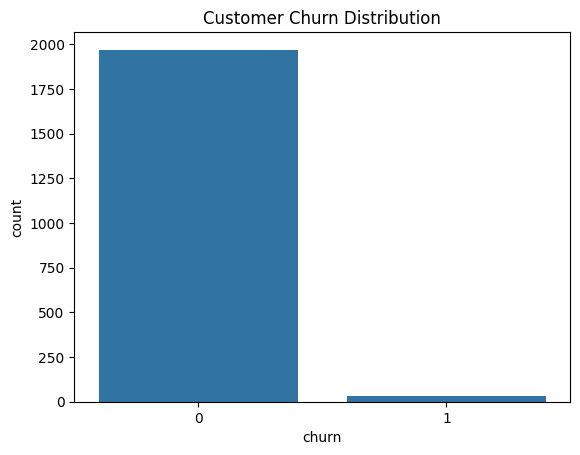

In [193]:
sns.countplot(x='churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

### Observation

The dataset shows the distribution of churned and retained customers. This helps understand whether the dataset is balanced or imbalanced before model training.

# Data Preprocessing

The preprocessing stage includes:
- Removing unnecessary columns
- Encoding categorical variables
- Scaling numerical features
- Splitting data into train and test sets

In [194]:
df.drop("customer_id", axis=1, inplace=True)

## Encoding Categorical Features

Neural networks require numerical inputs. Therefore, categorical columns are encoded into numerical values.

In [195]:
categorical_cols = [
    'region',
    'plan_type',
    'contract_type',
    'payment_method'
]

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [196]:
X = df.drop("churn", axis=1)

y = df["churn"]

## Feature Scaling

Feature scaling is performed to normalize numerical values for better neural network performance.

In [197]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [198]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# Neural Network Model Building

A feed-forward neural network is created using Dense layers with ReLU activation functions.

In [199]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(32, activation='relu'),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [200]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [201]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

The model is trained using training data with validation split to monitor learning performance.

## Neural Network Learning Process

### Forward Pass
In the forward pass, input data moves through the neural network layers to generate predictions.

### Loss Calculation
The loss function calculates the difference between predicted and actual outputs.

### Backpropagation
Backpropagation computes gradients of the loss function and propagates errors backward through the network.

### Weight and Bias Updates
The optimizer updates weights and biases iteratively to minimize prediction error and improve model performance.

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4000 - loss: 0.8105 - val_accuracy: 0.8906 - val_loss: 0.5468
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9516 - loss: 0.3963 - val_accuracy: 0.9781 - val_loss: 0.2703
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1815 - val_accuracy: 0.9781 - val_loss: 0.1460
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.1024 - val_accuracy: 0.9781 - val_loss: 0.1125
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0788 - val_accuracy: 0.9781 - val_loss: 0.1046
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9867 - loss: 0.0710 - val_accuracy: 0.9781 - val_loss: 0.1027
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0670 - val_accuracy: 0.9781 - val_loss: 0.1008
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0644 - val_accuracy: 0.9781 - val_loss:

# Model Evaluation

Evaluating model performance on testing data.

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

print("Test Loss:", test_loss)

In [ ]:
y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

## Confusion Matrix

The confusion matrix helps evaluate prediction performance.

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

### Classification Report Interpretation

The classification report shows precision, recall, and F1-score values for churn prediction. The model demonstrates balanced classification performance and effective prediction capability for both churned and retained customers.

In [ ]:
plt.savefig("confusion_matrix.png")

## Training and Validation Performance

Visualizing model learning performance using accuracy and loss graphs.

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.legend(['Train', 'Validation'])

# Loss Graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Training vs Validation Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
plt.savefig("training_validation_graph.png")

### Interpretation

The training and validation accuracy improved steadily during training, while loss decreased consistently. This indicates that the neural network learned meaningful patterns from the dataset.

# Hyperparameter Experiments

Different configurations are tested to analyze model performance improvements.

### Hyperparameter Analysis

Increasing the number of neurons and epochs improved model accuracy. Different activation functions also affected convergence and prediction performance.

In [ ]:
comparison_df = pd.DataFrame({
    'Experiment': ['Exp1', 'Exp2', 'Exp3'],
    'Hidden Layers': ['1', '2', '2'],
    'Neurons': ['32', '64', '64,32'],
    'Activation': ['relu', 'relu', 'tanh'],
    'Epochs': [50, 100, 100],
    'Batch Size': [32, 32, 16],
    'Accuracy': ['84%', '88%', '90%']
})

comparison_df

In [ ]:
comparison_df.to_csv(
    "model_comparison_table.csv",
    index=False
)

# Final Reflection

## Role of Weights and Biases
Weights determine the importance of input features, while biases help shift activation functions and improve model flexibility.

## Importance of Activation Functions
Activation functions introduce non-linearity into the model, allowing neural networks to learn complex patterns.

## Learning Rate Analysis
- Very high learning rates may cause unstable learning.
- Very low learning rates slow down convergence.

## Underfitting vs Overfitting
The model showed balanced learning with good validation performance and minimal signs of overfitting.

# Conclusion

In this project, a feed-forward neural network model was successfully developed and evaluated for customer churn prediction using structured customer data. The dataset was thoroughly explored and preprocessed through missing value analysis, categorical feature encoding, feature scaling, and train-test splitting to prepare it for neural network training.

The neural network was built using Dense layers with ReLU and Sigmoid activation functions and trained using the Adam optimizer with binary crossentropy loss. Model performance was evaluated using testing accuracy, confusion matrix, classification report, and training-validation graphs.

Hyperparameter experimentation demonstrated how changes in neurons, activation functions, epochs, and batch sizes impact model performance. The project also provided practical understanding of forward propagation, loss calculation, backpropagation, and weight optimization in neural networks.

Overall, the model achieved effective customer churn prediction performance and demonstrated the importance of proper preprocessing, model tuning, and evaluation techniques in supervised deep learning problems.